In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [3]:
COLS = [
    'Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA',
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
SENSORS = COLS[5:]
RUL_CAP = 125

BASELINE_N   = 10   # first N cycles to compute per-engine baseline
TREND_SMOOTH = 10   # smoothing window before slope
TREND_WINDOW = 20   # span over which slope is measured

# Physically motivated ratios: combustion, turbine, pressure, fan/core speed
RATIO_PAIRS = [
    ('T30', 'T24'),
    ('T50', 'T30'),
    ('P30', 'P2'),
    ('P30', 'P15'),
    ('NRf', 'NRc'),
]

In [4]:
def load_dataset(filename):
    df = pd.read_csv(f'../Data/{filename}', sep=' ', header=None).iloc[:, :26]
    df.columns = COLS
    max_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('max_cycle')
    df = df.join(max_cycle, on='Unit Number')
    df['RUL'] = df['max_cycle'] - df['Time (Cycles)']
    return df

offset = 0
parts = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_dataset(f'train_{fd}.txt')
    d['Unit Number'] += offset
    d['dataset'] = fd
    offset = d['Unit Number'].max()
    parts.append(d)

df_all = pd.concat(parts, ignore_index=True)
print(f'Loaded: {len(df_all):,} rows | {df_all["Unit Number"].nunique()} engines')

Loaded: 160,359 rows | 709 engines


In [5]:
def engineer_features(df):
    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        n = len(eng)
        new = {}

        # Baseline deviation
        cumean = eng[SENSORS].expanding(min_periods=1).mean()
        frozen = cumean.iloc[min(BASELINE_N - 1, n - 1)]
        for s in SENSORS:
            bl = np.where(np.arange(n) < BASELINE_N, cumean[s].values, frozen[s])
            new[f'{s}_dev'] = eng[s].values - bl

        # Trend (slope of smoothed signal)
        for s in SENSORS:
            sm = eng[s].rolling(TREND_SMOOTH, min_periods=1).mean()
            new[f'{s}_trend'] = sm.diff(TREND_WINDOW).fillna(0).values / TREND_WINDOW

        eng = pd.concat([eng, pd.DataFrame(new, index=eng.index)], axis=1)
        parts.append(eng)
    return pd.concat(parts, ignore_index=True)

print('Engineering features...')
df_feat = engineer_features(df_all)

# Sensor ratios — current-cycle column ops, no per-engine history needed
RATIO_COLS = []
for num, den in RATIO_PAIRS:
    col = f'{num}_over_{den}'
    df_feat[col] = df_feat[num] / df_feat[den].clip(lower=1e-6)
    RATIO_COLS.append(col)

DEV_COLS   = [f'{s}_dev'   for s in SENSORS]
TREND_COLS = [f'{s}_trend' for s in SENSORS]
FEATURE_COLS = SENSORS + DEV_COLS + TREND_COLS + RATIO_COLS + ['Time (Cycles)']

# Sanity checks
assert not df_feat[FEATURE_COLS].isnull().any().any(), 'NaN in features'
assert not np.isinf(df_feat[RATIO_COLS].values).any(), 'Inf in ratio features'
print(f'Done — {len(FEATURE_COLS)} features ({len(SENSORS)} raw + {len(DEV_COLS)} dev + {len(TREND_COLS)} trend + {len(RATIO_COLS)} ratios + 1 cycle)')

Engineering features...
Done — 69 features (21 raw + 21 dev + 21 trend + 5 ratios + 1 cycle)


In [6]:
engines = df_all[['Unit Number', 'dataset']].drop_duplicates()
train_engines, test_engines = train_test_split(
    engines, test_size=0.2, random_state=42, stratify=engines['dataset']
)

train_df = df_feat[df_feat['Unit Number'].isin(train_engines['Unit Number'])].copy()
test_df  = df_feat[df_feat['Unit Number'].isin(test_engines['Unit Number'])].copy()

print(f"Train: {train_df['Unit Number'].nunique()} engines, {len(train_df):,} rows")
print(f"Test:  {test_df['Unit Number'].nunique()} engines, {len(test_df):,} rows")

y_train_reg = train_df['RUL'].clip(upper=RUL_CAP)
y_test_reg  = test_df['RUL'].clip(upper=RUL_CAP)

THRESHOLDS   = [5, 15, 20, 25, 50]
CLASS_LABELS = ['<=5', '6-15', '16-20', '21-25', '26-50', '>50']

def rul_to_class(rul):
    for i, t in enumerate(THRESHOLDS):
        if rul <= t: return i
    return len(THRESHOLDS)

y_train_cls = train_df['RUL'].apply(rul_to_class)
y_test_cls  = test_df['RUL'].apply(rul_to_class)

Train: 567 engines, 128,042 rows
Test:  142 engines, 32,317 rows


## XGBoost Classifier

| Class | Meaning |
|---|---|
| 0 | RUL <= 5 cycles |
| 1 | 6–15 cycles |
| 2 | 16–20 cycles |
| 3 | 21–25 cycles |
| 4 | 26–50 cycles |
| 5 | > 50 cycles |

In [7]:
clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=len(CLASS_LABELS),
    random_state=42, n_jobs=-1,
    eval_metric='mlogloss', early_stopping_rounds=20,
)
clf.fit(train_df[FEATURE_COLS], y_train_cls,
        eval_set=[(test_df[FEATURE_COLS], y_test_cls)], verbose=50)

[0]	validation_0-mlogloss:0.80238
[50]	validation_0-mlogloss:0.39608
[100]	validation_0-mlogloss:0.34457
[150]	validation_0-mlogloss:0.32347
[200]	validation_0-mlogloss:0.30967
[250]	validation_0-mlogloss:0.30100
[299]	validation_0-mlogloss:0.29552


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_

              precision    recall  f1-score   support

         <=5       0.73      0.73      0.73       852
        6-15       0.56      0.73      0.63      1420
       16-20       0.45      0.10      0.16       710
       21-25       0.42      0.06      0.11       710
       26-50       0.61      0.64      0.63      3550
         >50       0.96      0.98      0.97     25075

    accuracy                           0.88     32317
   macro avg       0.62      0.54      0.54     32317
weighted avg       0.87      0.88      0.87     32317



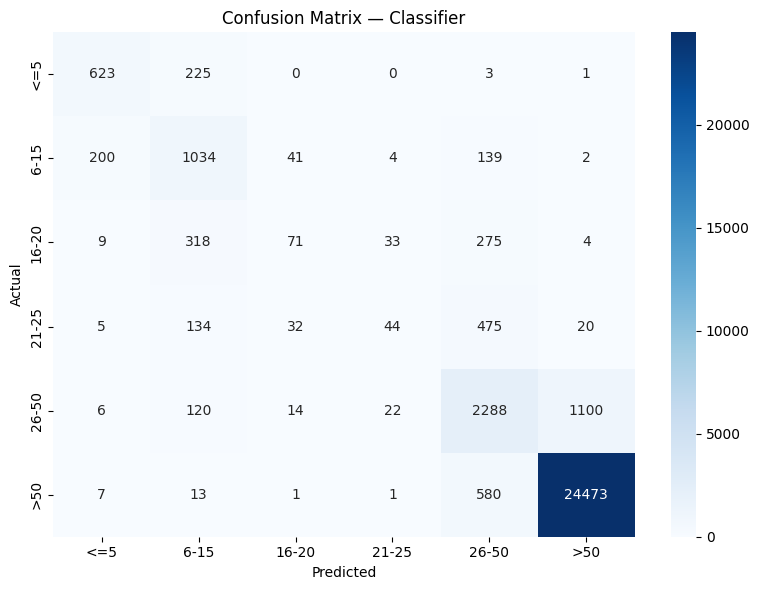

In [8]:
y_pred_cls = clf.predict(test_df[FEATURE_COLS])
print(classification_report(y_test_cls, y_pred_cls, target_names=CLASS_LABELS))

cm = confusion_matrix(y_test_cls, y_pred_cls)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Classifier')
plt.tight_layout(); plt.show()

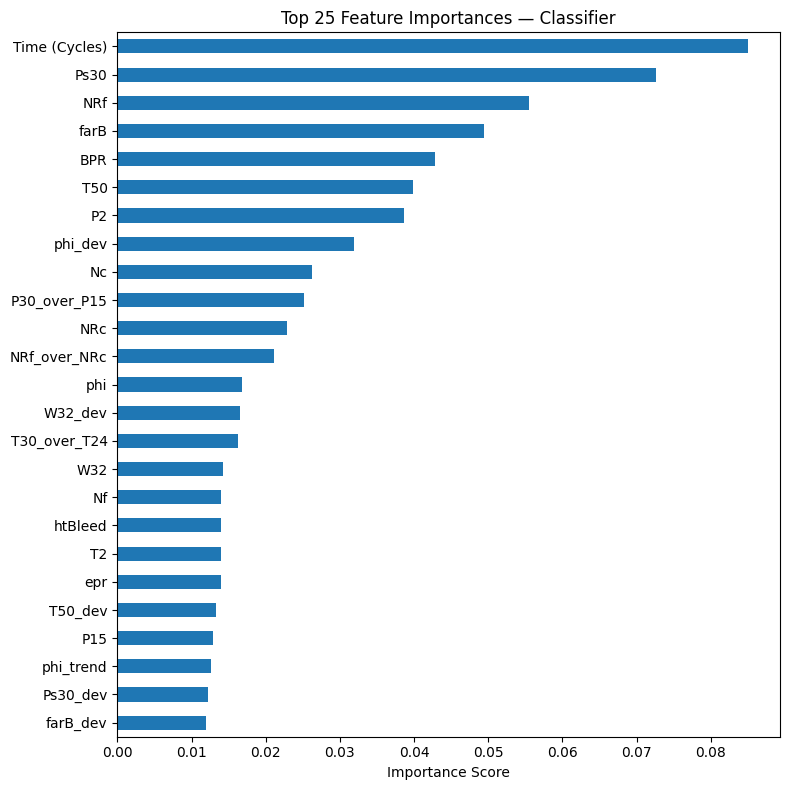

In [9]:
feat_imp_clf = pd.Series(clf.feature_importances_, index=FEATURE_COLS).nlargest(25)
fig, ax = plt.subplots(figsize=(8, 8))
feat_imp_clf.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 25 Feature Importances — Classifier')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

In [10]:
reg = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42, n_jobs=-1,
    eval_metric='rmse', early_stopping_rounds=20,
)
reg.fit(train_df[FEATURE_COLS], y_train_reg,
        eval_set=[(test_df[FEATURE_COLS], y_test_reg)], verbose=50)

[0]	validation_0-rmse:39.70835
[50]	validation_0-rmse:17.26528
[100]	validation_0-rmse:15.89075
[150]	validation_0-rmse:15.57830
[200]	validation_0-rmse:15.43202
[250]	validation_0-rmse:15.32371
[299]	validation_0-rmse:15.22805


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


MAE:  10.25 cycles
RMSE: 15.23 cycles
R2:   0.8634


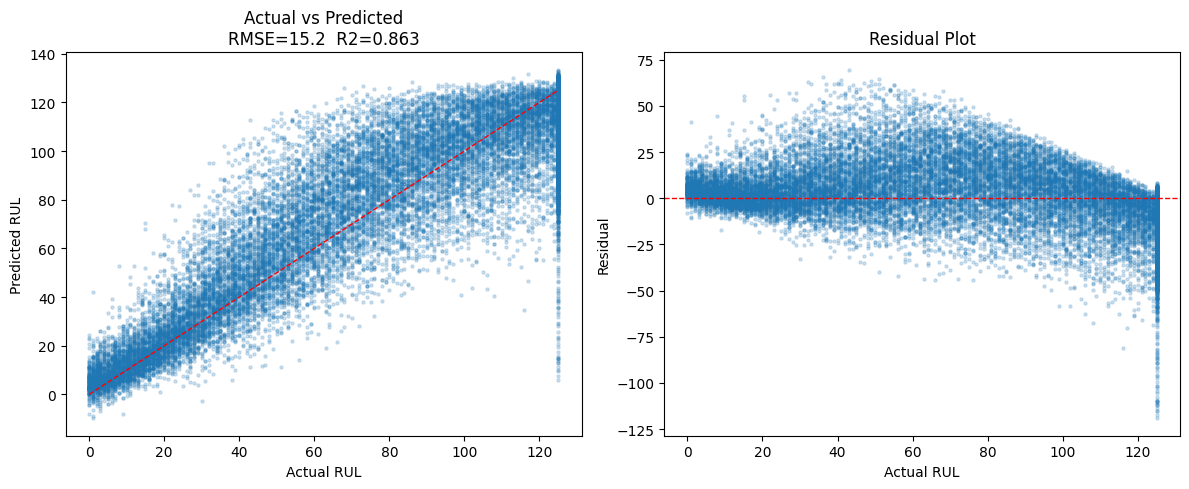

In [11]:
y_pred_reg = reg.predict(test_df[FEATURE_COLS])
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2   = r2_score(y_test_reg, y_pred_reg)
print(f'MAE:  {mae:.2f} cycles')
print(f'RMSE: {rmse:.2f} cycles')
print(f'R2:   {r2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.2, s=5)
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], 'r--', lw=1)
axes[0].set_xlabel('Actual RUL'); axes[0].set_ylabel('Predicted RUL')
axes[0].set_title(f'Actual vs Predicted\nRMSE={rmse:.1f}  R2={r2:.3f}')
residuals = y_pred_reg - y_test_reg.values
axes[1].scatter(y_test_reg, residuals, alpha=0.2, s=5)
axes[1].axhline(0, color='r', lw=1, ls='--')
axes[1].set_xlabel('Actual RUL'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')
plt.tight_layout(); plt.show()

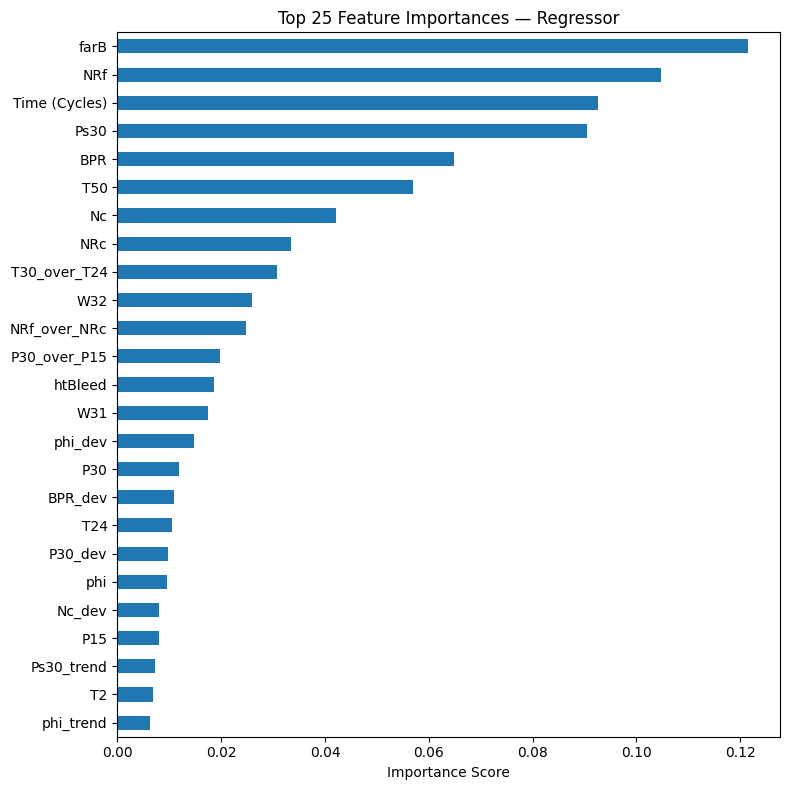

In [12]:
feat_imp_reg = pd.Series(reg.feature_importances_, index=FEATURE_COLS).nlargest(25)
fig, ax = plt.subplots(figsize=(8, 8))
feat_imp_reg.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 25 Feature Importances — Regressor')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

In [13]:
def load_nasa_test(fd):
    df = pd.read_csv(f'../Data/test_{fd}.txt', sep=' ', header=None).iloc[:, :26]
    df.columns = COLS
    rul_gt = pd.read_csv(f'../Data/RUL_{fd}.txt', header=None, names=['true_rul'])
    rul_gt['Unit Number'] = rul_gt.index + 1
    last_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('last_cycle')
    df = df.join(last_cycle, on='Unit Number')
    df = df.join(rul_gt.set_index('Unit Number')['true_rul'], on='Unit Number')
    df['RUL'] = (df['last_cycle'] + df['true_rul']) - df['Time (Cycles)']
    return df

offset = 0
nasa_parts = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_nasa_test(fd)
    d['Unit Number'] += offset
    d['dataset'] = fd
    offset = d['Unit Number'].max()
    nasa_parts.append(d)
nasa_raw = pd.concat(nasa_parts, ignore_index=True)

print('Engineering features on NASA test set...')
nasa_feat = engineer_features(nasa_raw)
for num, den in RATIO_PAIRS:
    nasa_feat[f'{num}_over_{den}'] = nasa_feat[num] / nasa_feat[den].clip(lower=1e-6)

print(f'NASA test: {nasa_feat["Unit Number"].nunique()} engines, {len(nasa_feat):,} rows')

Engineering features on NASA test set...
NASA test: 707 engines, 104,897 rows


In [14]:
n_nasa = nasa_feat['Unit Number'].nunique()

# Classifier policy
nasa_clf = nasa_feat.copy()
nasa_clf['pred_class'] = clf.predict(nasa_clf[FEATURE_COLS])

policy_clf = []
for trigger_class in range(len(CLASS_LABELS)):
    wasted, missed = [], 0
    for unit, eng in nasa_clf.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').reset_index(drop=True)
        triggered = eng['pred_class'] <= trigger_class
        if triggered.any():
            wasted.append(eng.loc[triggered.idxmax(), 'RUL'])
        else:
            missed += 1
    policy_clf.append({
        'Trigger when predicted class is': CLASS_LABELS[trigger_class],
        'Engines caught (%)': round((n_nasa - missed) / n_nasa * 100, 1),
        'Missed': missed,
        'Avg wasted cycles': round(float(np.mean(wasted)), 1) if wasted else None,
        'Median wasted cycles': round(float(np.median(wasted)), 1) if wasted else None,
    })

df_policy_clf = pd.DataFrame(policy_clf)
print('=== Classifier maintenance policy (NASA test set) ===')
print(df_policy_clf.to_string(index=False))
print()

# Regressor policy
nasa_reg = nasa_feat.copy()
nasa_reg['pred_rul'] = reg.predict(nasa_reg[FEATURE_COLS])

REPAIR_THRESHOLDS = [5, 10, 15, 20, 25, 30, 40, 50]
policy_reg = []
for threshold in REPAIR_THRESHOLDS:
    wasted, missed = [], 0
    for unit, eng in nasa_reg.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').reset_index(drop=True)
        triggered = eng['pred_rul'] <= threshold
        if triggered.any():
            wasted.append(eng.loc[triggered.idxmax(), 'RUL'])
        else:
            missed += 1
    policy_reg.append({
        'Repair when pred RUL <=': threshold,
        'Engines caught (%)': round((n_nasa - missed) / n_nasa * 100, 1),
        'Missed': missed,
        'Avg wasted cycles': round(float(np.mean(wasted)), 1) if wasted else None,
        'Median wasted cycles': round(float(np.median(wasted)), 1) if wasted else None,
    })

df_policy_reg = pd.DataFrame(policy_reg)
print('=== Regressor maintenance policy (NASA test set) ===')
print(df_policy_reg.to_string(index=False))

=== Classifier maintenance policy (NASA test set) ===
Trigger when predicted class is  Engines caught (%)  Missed  Avg wasted cycles  Median wasted cycles
                            <=5                 5.5     668               23.1                  12.0
                           6-15                17.5     583               26.9                  21.5
                          16-20                19.2     571               27.1                  22.0
                          21-25                19.4     570               27.7                  23.0
                          26-50                38.3     436               62.3                  55.0
                            >50               100.0       0              228.8                 214.0

=== Regressor maintenance policy (NASA test set) ===
 Repair when pred RUL <=  Engines caught (%)  Missed  Avg wasted cycles  Median wasted cycles
                       5                 4.1     678               24.2                  10

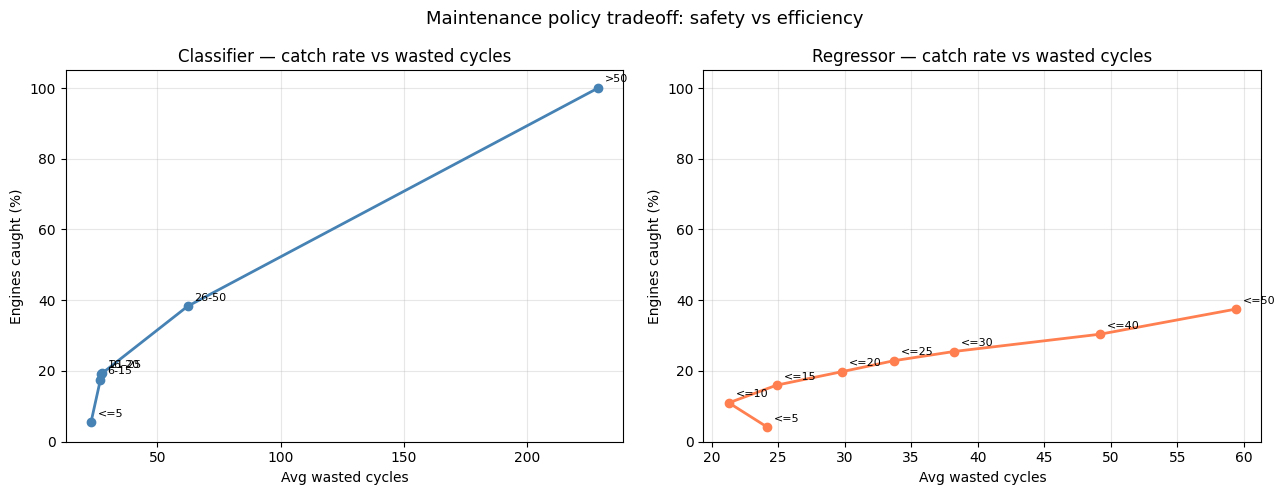

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clf_x = df_policy_clf['Avg wasted cycles'].dropna()
clf_y = df_policy_clf.loc[clf_x.index, 'Engines caught (%)']
clf_lbl = df_policy_clf.loc[clf_x.index, 'Trigger when predicted class is']
axes[0].plot(clf_x, clf_y, 'o-', color='steelblue', lw=2)
for x, y, l in zip(clf_x, clf_y, clf_lbl):
    axes[0].annotate(l, (x, y), textcoords='offset points', xytext=(5, 4), fontsize=8)
axes[0].set_xlabel('Avg wasted cycles'); axes[0].set_ylabel('Engines caught (%)')
axes[0].set_title('Classifier — catch rate vs wasted cycles')
axes[0].set_ylim(0, 105); axes[0].grid(True, alpha=0.3)

reg_x = df_policy_reg['Avg wasted cycles'].dropna()
reg_y = df_policy_reg.loc[reg_x.index, 'Engines caught (%)']
reg_lbl = df_policy_reg.loc[reg_x.index, 'Repair when pred RUL <='].astype(str)
axes[1].plot(reg_x, reg_y, 'o-', color='coral', lw=2)
for x, y, l in zip(reg_x, reg_y, reg_lbl):
    axes[1].annotate(f'<={l}', (x, y), textcoords='offset points', xytext=(5, 4), fontsize=8)
axes[1].set_xlabel('Avg wasted cycles'); axes[1].set_ylabel('Engines caught (%)')
axes[1].set_title('Regressor — catch rate vs wasted cycles')
axes[1].set_ylim(0, 105); axes[1].grid(True, alpha=0.3)

fig.suptitle('Maintenance policy tradeoff: safety vs efficiency', fontsize=13)
plt.tight_layout(); plt.show()